# Output

**What this shows:** how to choose where SWAN writes output (grids, points, lines),
what it writes (maps, tables, spectra), when it writes, and how to read each file.

**Prerequisites:** [Tutorial 6: A nonstationary hindcast](../tutorial/06_nonstationary_hindcast.ipynb).

**You will learn:**

- the output locations: `COMPGRID`, `FRAME`, `GROUP`, `POINTS`, `CURVE` and `RAY` with
  `ISOLINE`
- the write components `BLOCK`/`BLOCKS`, `TABLE` and `SPECOUT`, and the file formats
- how output times follow the run period, and how to start output later
- how to set quantity options such as the swell cut-off frequency

**Data used:** `etopo15s_perth.nc`, `era5-20230101.nc` and
`ww3-spectra-20230101-short.nc`, for a three-hour run.

## Setup

In [1]:
import shutil
import subprocess
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_swan.boundary import Boundnest1
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_NONSTAT
from rompy_swan.components.output import (
    BLOCK,
    BLOCKS,
    CURVE,
    CURVES,
    FRAME,
    POINTS,
    QUANTITIES,
    QUANTITY,
    SPECOUT,
    TABLE,
)
from rompy_swan.components.physics import FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface
from rompy_swan.subcomponents.output import SPEC1D
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL
from rompy_swan.subcomponents.time import TimeRangeOpen

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "output"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Output locations

Output is written at named sets of locations (`sname`, at most 8 characters):

| Component | Locations |
|---|---|
| `COMPGRID` (special name) | the computational grid; `BOTTGRID` is the bottom grid |
| `FRAME` | a regular grid of its own, e.g. a finer view of an area |
| `GROUP` | a sub-grid of the computational grid, by indices |
| `POINTS` | individual points |
| `CURVE` | points along a line, e.g. a transect to the coast |
| `RAY` + `ISOLINE` | points along a depth or bottom contour |

Here: a frame off Perth, a transect across the shelf to Cottesloe, and two points.

In [2]:
frame = FRAME(
    sname="perth", grid=dict(xp=115.5, yp=-32.2, alp=0.0, xlen=0.3, ylen=0.4, mx=30, my=40)
)
transect = CURVES(
    curves=[CURVE(sname="transect", xp1=115.3, yp1=-31.98, npts=[44], xp=[115.74], yp=[-31.98])]
)
points = POINTS(sname="sites", xp=[114.8, 115.71], yp=[-32.1, -31.98])
for location in [frame, transect, points]:
    print(location.render())

FRAME sname='perth' xpfr=115.5 ypfr=-32.2 alpfr=0.0 xlenfr=0.3 ylenfr=0.4 mxfr=30 myfr=40
CURVE sname='transect' xp1=115.3 yp1=-31.98 &
    int=44 xp=115.74 yp=-31.98
POINTS sname='sites' &
    xp=114.8 yp=-32.1 &
    xp=115.71 yp=-31.98


## 2. What to write

- `BLOCK` writes maps on `COMPGRID`, a `FRAME` or a `GROUP`; `BLOCKS` holds several;
- `TABLE` writes values at points, curves or rays, with `HEADER`, `NOHEADER` or
  `INDEXED` layout;
- `SPECOUT` writes spectra, 2D (`SPEC2D`) or 1D (`SPEC1D`), absolute or relative
  frequencies.

The file extension sets the format: `.nc` for NetCDF, `.mat` for MATLAB, anything else
for text. rompy-swan fills in the output times from the run period (start and
interval). A `times` with `delt` changes the interval, and a `tbeg` starts later, for
example after the spin-up.

In [3]:
start = datetime(2023, 1, 1)
maps = BLOCKS(
    components=[
        BLOCK(sname="perth", fname="perth.nc", output=["depth", "hsign", "dir"]),
        BLOCK(
            sname="COMPGRID",
            fname="swangrid.nc",
            output=["hsign", "hswell"],
            times=TimeRangeOpen(tbeg=start + timedelta(hours=1), delt=timedelta(hours=1)),
        ),
    ]
)
table = TABLE(
    sname="transect", format="noheader", fname="transect.txt", output=["xp", "depth", "hsign", "setup"]
)
spectra = SPECOUT(sname="sites", dim=SPEC1D(), fname="spec1d.nc")

`QUANTITY` changes how a quantity is computed or written. Here the swell height
`HSWELL` counts energy below 0.1 Hz (periods above 10 s):

In [4]:
quantity = QUANTITIES(quantities=[QUANTITY(output=["hswell"], fswell=0.1)])
output = OUTPUT(
    frame=frame,
    curve=transect,
    points=points,
    quantity=quantity,
    block=maps,
    table=table,
    specout=spectra,
)
print(output.render())

FRAME sname='perth' xpfr=115.5 ypfr=-32.2 alpfr=0.0 xlenfr=0.3 ylenfr=0.4 mxfr=30 myfr=40

CURVE sname='transect' xp1=115.3 yp1=-31.98 &
    int=44 xp=115.74 yp=-31.98

POINTS sname='sites' &
    xp=114.8 yp=-32.1 &
    xp=115.71 yp=-31.98

QUANTITY HSWELL fswell=0.1

BLOCK sname='perth' fname='perth.nc' &
    DEPTH &
    HSIGN &
    DIR

BLOCK sname='COMPGRID' fname='swangrid.nc' &
    HSIGN &
    HSWELL &
    OUTPUT tbegblk=20230101.010000 deltblk=3600.0 SEC

TABLE sname='transect' NOHEADER fname='transect.txt' &
    XP &
    DEPTH &
    HSIGN &
    SETUP

SPECOUT sname='sites' SPEC1D fname='spec1d.nc'


## 3. A short run

The model of Tutorial 6, over three hours:

In [5]:
grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
config = SwanConfig(
    startup=STARTUP(
        set=SET(direction_convention="nautical"),
        mode=MODE(kind="nonstationary"),
        coordinates=COORDINATES(kind=SPHERICAL()),
    ),
    cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
    inpgrid=DataInterface(
        bottom=SwanDataGrid(
            var="bottom",
            source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
            z1="z",
            fac=-1.0,
            coords={"x": "longitude", "y": "latitude"},
            buffer=0.1,
        ),
        input=[
            SwanDataGrid(
                var="wind",
                source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
                z1="u10",
                z2="v10",
                coords={"x": "longitude", "y": "latitude"},
                filter=Filter(sort={"coords": ["latitude"]}),
                buffer=0.25,
            )
        ],
    ),
    boundary=BoundaryInterface(
        kind=Boundnest1(
            id="ww3",
            source=SourceWavespectra(
                uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
            ),
            sel_method="idw",
            sel_method_kwargs={"tolerance": 1.5},
            spacing=0.1,
        )
    ),
    physics=PHYSICS(gen=GEN3(), friction=FRICTION_JONSWAP(cfjon=0.038), triad=TRIAD()),
    output=output,
    lockup=LOCKUP(compute=COMPUTE_NONSTAT(initstat=True)),
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T03:00", interval="10m")
modelrun = ModelRun(run_id="output", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
input_file = (workspace / "INPUT").read_text()
print("\n".join(line for line in input_file.splitlines() if "OUTPUT tbeg" in line))

    OUTPUT tbegblk=20230101.000000 deltblk=600.0 SEC
    OUTPUT tbegblk=20230101.010000 deltblk=3600.0 SEC
    OUTPUT tbegtbl=20230101.000000 delttbl=600.0 SEC
SPECOUT sname='sites' SPEC1D fname='spec1d.nc' OUTPUT tbegspc=20230101.000000 deltspc=600.0 SEC


In [6]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
    ok = modelrun.run(backend, workspace_dir=workspace)
    print("SWAN finished" if ok else "SWAN failed")
else:
    print("Docker is not available, skipping the model run")

SWAN finished


## 4. Reading the output

The frame and the delayed `COMPGRID` maps are NetCDF files: the frame has an output
every 10 minutes (the run interval), the other one every hour from 01:00. SWAN names
the variables with short names, e.g. `hs` for `HSIGN` and `hswe` for `HSWELL`.

In [7]:
if (workspace / "perth.nc").exists():
    frame_maps = xr.open_dataset(workspace / "perth.nc")
    grid_maps = xr.open_dataset(workspace / "swangrid.nc")
    print("frame times:", frame_maps.time.size, "from", frame_maps.time.values[0])
    print("grid times: ", grid_maps.time.values)

frame times: 19 from 2023-01-01T00:00:00.000000000
grid times:  ['2023-01-01T01:00:00.000000000' '2023-01-01T02:00:00.000000000'
 '2023-01-01T03:00:00.000000000']


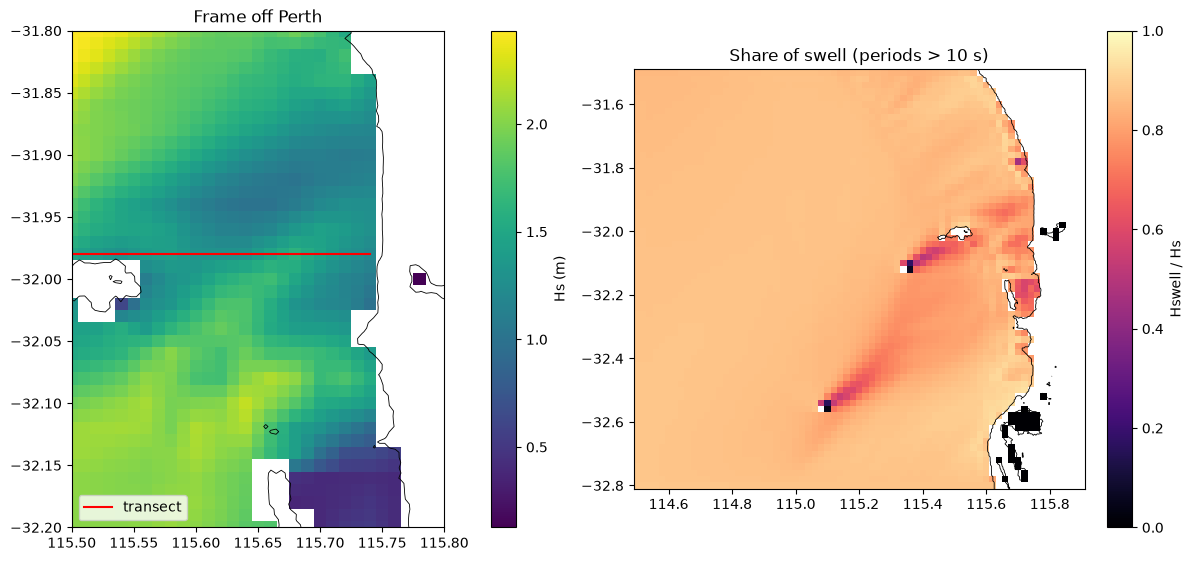

In [8]:
if (workspace / "perth.nc").exists():
    etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
    last = grid_maps.isel(time=-1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), layout="constrained")
    frame_maps.hs.isel(time=-1).plot(ax=axes[0], cmap="viridis", cbar_kwargs={"label": "Hs (m)"})
    (last.hswe / last.hs).plot(ax=axes[1], cmap="magma", vmin=0, vmax=1, cbar_kwargs={"label": "Hswell / Hs"})
    axes[0].plot([115.3, 115.74], [-31.98, -31.98], "r", label="transect")
    axes[0].legend(loc="lower left")
    for ax, title in zip(axes, ["Frame off Perth", "Share of swell (periods > 10 s)"]):
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        ax.set(title=title, xlabel="", ylabel="")
        ax.set_aspect("equal")
    axes[0].set(xlim=(115.5, 115.8), ylim=(-32.2, -31.8))

The table without header has one row per point along the transect (45 points, from
`npts=44` segments) for each output time. It writes numbers with four significant
digits, so the positions are taken from the curve definition. Across the shelf the
waves lose energy to bottom friction and in the lee of the reefs, and grow briefly
where they shoal over the bank near 115.68°E:

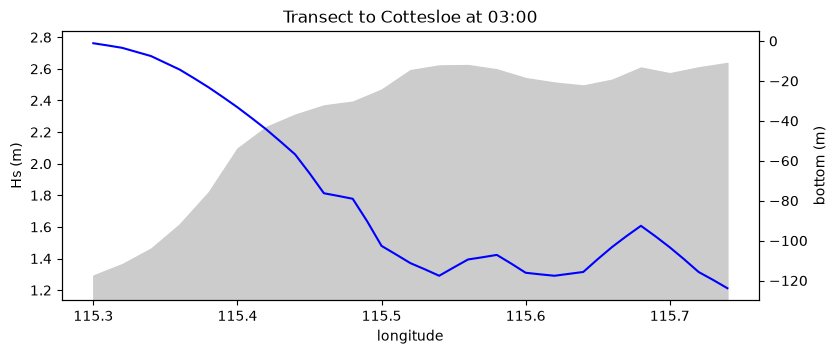

In [9]:
if (workspace / "transect.txt").exists():
    rows = pd.read_csv(workspace / "transect.txt", sep=r"\s+", names=["xp", "depth", "hs", "setup"])
    last_time = rows.tail(45).assign(lon=np.linspace(115.3, 115.74, 45))
    fig, ax1 = plt.subplots(figsize=(9, 3.5))
    ax1.plot(last_time.lon, last_time.hs, "b")
    ax1.set(xlabel="longitude", ylabel="Hs (m)")
    ax2 = ax1.twinx()
    ax2.fill_between(last_time.lon, -last_time.depth, -130, color="0.8")
    ax2.set(ylabel="bottom (m)", ylim=(-130, 5))
    ax1.set_zorder(ax2.get_zorder() + 1)  # draw the wave height above the bottom
    ax1.patch.set_visible(False)
    ax1.set_title("Transect to Cottesloe at 03:00")

Setup is -9 (the exception value) because the model has no `SETUP` physics.

The 1D spectra file holds the energy density, mean direction and spreading per
frequency at each point, every 10 minutes:

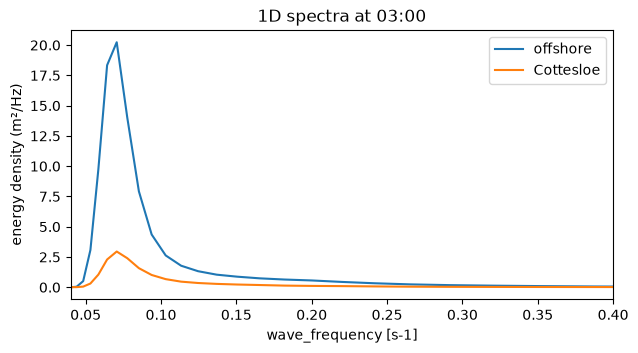

In [10]:
if (workspace / "spec1d.nc").exists():
    spec1d = xr.open_dataset(workspace / "spec1d.nc").isel(time=-1)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    for point, name in enumerate(["offshore", "Cottesloe"]):
        spec1d.energy_1d.isel(points=point).plot(ax=ax, label=name)
    ax.set(xlim=(0.04, 0.4), ylabel="energy density (m²/Hz)", title="1D spectra at 03:00")
    ax.legend()

## Summary

- Output locations: `COMPGRID`, `FRAME`, `GROUP`, `POINTS`, `CURVE`, `RAY`/`ISOLINE`.
- `BLOCK`/`BLOCKS` write maps, `TABLE` values at locations, `SPECOUT` spectra; `.nc`
  gives NetCDF.
- Output times follow the run period; `times` changes the interval or starts later.
- `QUANTITY` sets options such as the swell cut-off `fswell`.